In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from utils import get_partition_distances, plot_heatmap_idsxfam

In [22]:
splits = pd.read_csv("./data/2_fam_folds/split.csv")
save_path = "./images/2_fam_folds/"
print(splits.head(2))
DIST_PATH = "../data/rnadist_f_all.h5"
dist = pd.read_hdf(DIST_PATH)
dist.head(2)

  fold_name  fold_number partition                           id
0      grp1            0     train  5s_Acholeplasma-laidlawii-1
1      grp1            0     train    5s_Acidovorax-temperans-1


id,5s_Acholeplasma-laidlawii-1,5s_Acidovorax-temperans-1,tmRNA_Stre.gord._TRW-29390_1-349,tRNA_tdbR00000055-Schizosaccharomyces_pombe-4896-Glu-3UC,srp_List.mono._U15684,5s_Methanothermobacter-thermautotrophicus-6,srp_Vibr.fisc._CP000020,srp_Baci.thur._D11412,grp1_a.I1.m.M.grisea.B2.ND1,5s_Saprospira-grandis-1,...,RNaseP_M.avium,tRNA_tdbR00000521-Bos_taurus-9913-Ini-CAU,grp1_a.I1.e.P.pachydermus.C1.SSU.943,5s_Pseudomonas-stutzeri-2,16s_T.maritima_domain3,5s_Bacillus-cereus-6,srp_Myco.aviu._AE016958,tmRNA_Heli.pylo._AE001503_1-383,5s_Triticum-aestivum-1,5s_Streptomyces-violaceus-1
id,,,,,,,,,,,,,,,,,,,,,
5s_Acholeplasma-laidlawii-1,0.000000,0.130435,0.805158,0.562500,0.799283,0.265625,0.776786,0.756458,0.782456,0.173554,...,0.763819,0.625000,0.795918,0.150000,0.817734,0.140351,0.696429,0.806789,0.200000,0.216667
5s_Acidovorax-temperans-1,0.130435,0.000000,0.819484,0.591304,0.802867,0.179688,0.747826,0.752768,0.778947,0.132231,...,0.756281,0.652174,0.798469,0.108333,0.815271,0.130435,0.756522,0.814621,0.191667,0.125000


In [60]:

# ids y familias
ids = dist.index
ids = sorted(set(ids))
fams_list = [id.split("_")[0] for id in ids]
unique_fams = sorted(set(fams_list))

# construir dfs por familia
dfs = {}
for fam in unique_fams:
    cols = [id for id, f in zip(ids, fams_list) if f == fam] 
    rows = ids.copy()
    sdf = dist.loc[rows, cols].copy()
    
    row_ids = np.array(ids)[np.array(fams_list) == fam]
    sdf.loc[row_ids, :] = np.nan
    
    dfs[fam] = sdf

cmap = plt.cm.get_cmap("tab10", len(unique_fams))
fam2color = {fam: cmap(i) for i, fam in enumerate(unique_fams)}
id2fam = dict(zip(ids, fams_list))


/tmp/ipykernel_1388719/1989818544.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_fams))


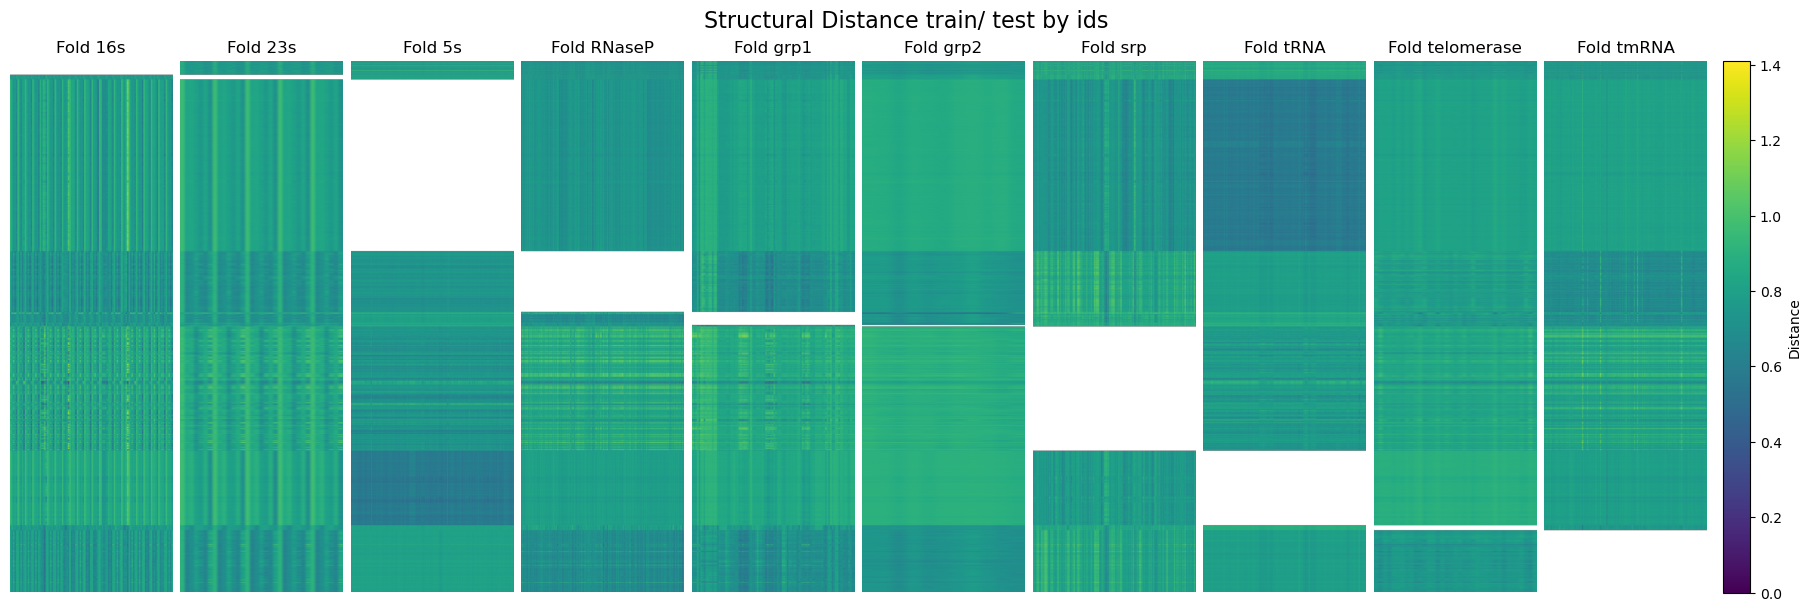

In [61]:
fig, axes = plt.subplots(1, len(unique_fams), figsize=(18, 6), constrained_layout=True)

vmin, vmax = 0, 1.41  # escala fija
for i, fold in enumerate(unique_fams):
    mat = dfs[fold].values
    im = axes[i].imshow(mat, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    axes[i].set_title(f"Fold {fold}")
    axes[i].axis('off')  # quita los ticks/labels

# agregar barra de color única
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label("Distance")

plt.suptitle("Structural Distance train/ test by ids", fontsize=16)
# plt.savefig(save_path+"heatmap_ids.pdf")
plt.show()


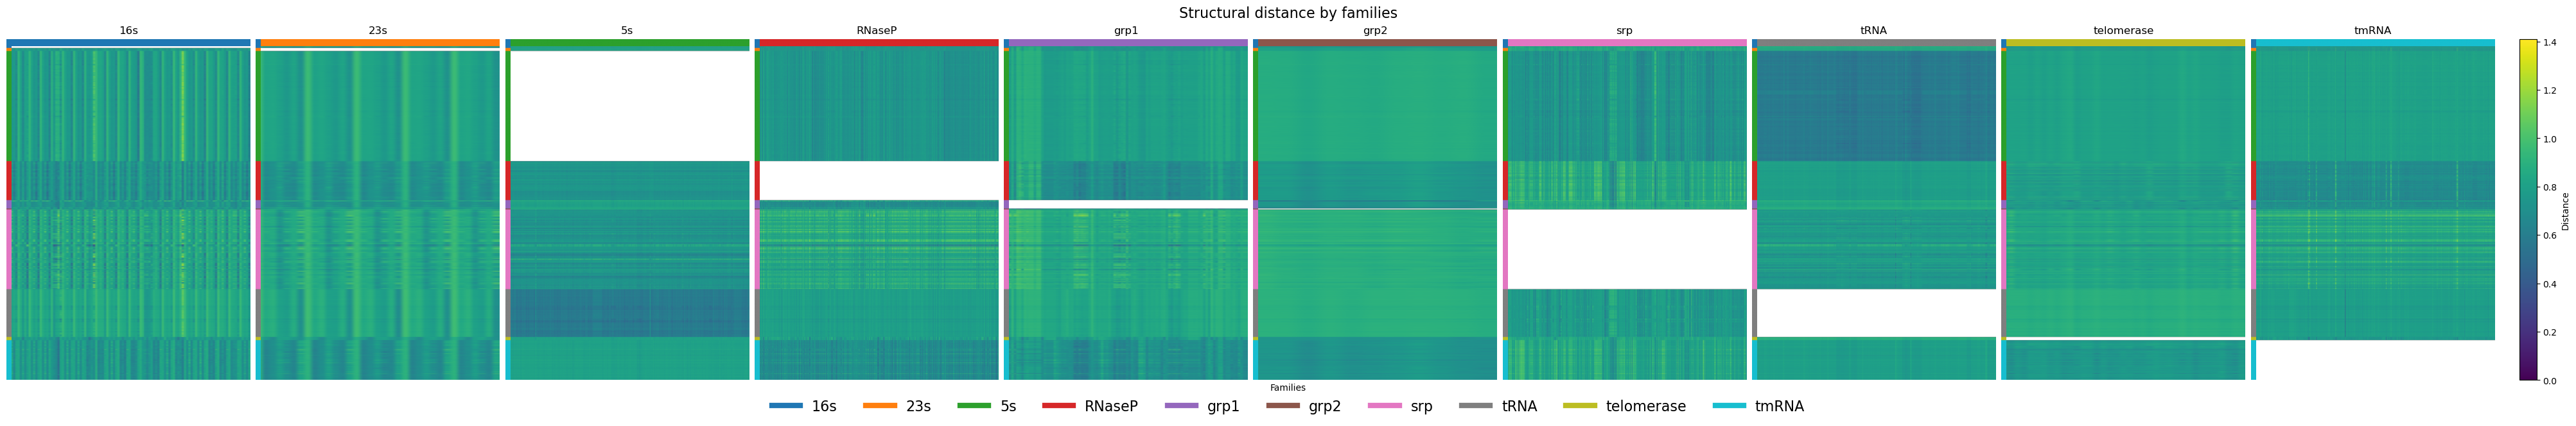

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# plot
fig, axes = plt.subplots(1, len(dfs), figsize=(4*len(dfs), 6), constrained_layout=True)

vmin, vmax = 0, 1.41
for i, (fam, mat) in enumerate(dfs.items()):
    ax = axes[i] if len(dfs) > 1 else axes
    im = ax.imshow(mat.values, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(f"{fam}")
    ax.axis("off")
    
    # colores filas y columnas
    row_colors = [fam2color[id2fam[i]] for i in mat.index]
    col_colors = [fam2color[id2fam[i]] for i in mat.columns]
    
    # barrita arriba
    ax_top = inset_axes(ax, width="100%", height="2%", loc="upper center",
                        bbox_to_anchor=(0,0,1,1), bbox_transform=ax.transAxes, borderpad=0)
    ax_top.imshow([col_colors], aspect="auto")
    ax_top.axis("off")
    
    # barrita izquierda
    ax_left = inset_axes(ax, width="2%", height="100%", loc="center left",
                         bbox_to_anchor=(0,0,1,1), bbox_transform=ax.transAxes, borderpad=0)
    ax_left.imshow(np.array(row_colors)[:, None].reshape(-1,1,4), aspect="auto")
    ax_left.axis("off")

# colorbar única
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label("Distance")

# leyenda abajo
handles = [plt.Line2D([0], [0], color=fam2color[f], lw=6) for f in unique_fams]
fig.legend(handles, unique_fams, title="Families",
           loc='lower center', ncol=len(unique_fams),
           bbox_to_anchor=(0.5, -0.1), frameon=False, fontsize=16)

plt.suptitle("Structural distance by families", fontsize=16)
plt.show()
